# Voltas AC IR Protocol Analysis

**Research objective:** Decode the infrared protocol used by this Voltas window AC so that a custom ESPHome climate component can reproduce its remote commands.

## Capture Setup

```yaml
remote_receiver:
  pin: GPIO5
  dump: all
  id: ir_receiver
```

The ESPHome logs look like this when the remote buttons are pressed:

```
[01:03:00.980][I][remote.pronto:239]: 0000 006D 0051 0000 0029 0015 0029 0015 0029 0062 0028 0062 0028 0016 0028 0015 0029 0062 0029 0063 0029 0014 0029 0016 0028 0063 0028 0016 0028 0062 0029 0016 0028 0015 0029 0016 0028 0063 0028 0016 0028 0016 0028 0016 0028 0063
[01:03:00.980][I][remote.pronto:239]: 0028 0016 0028 0016 0028 0016 0028 0016 0028 0016 0028 0016 0028 0063 0028 0063 0028 0016 0028 0016 0028 0016 0028 0016 0028 0016 0028 0063 0028 0063 0029 0062 0028 0016 0028 0063 0028 0063 0028 0016 0029 0015 0029 0062 0028 0063
[01:03:01.008][I][remote.pronto:239]: 0029 0062 0028 0016 0029 0062 0028 0063 0028 0016 0029 0015 0028 0063 0028 0063 0028 0063 0028 0016 0028 0063 0029 0062 0028 0016 0028 0016 0028 0016 0028 0063 0028 0016 0028 0016 0028 0016 0029 0062 0028 0016 0029 0015 0028 0016
[01:03:01.018][I][remote.pronto:239]: 0029 0015 0028 0016 0029 0015 0028 0016 0029 0015 0028 0016 0028 0063 0028 0016 0028 0016 0029 0015 0028 0016 0029 0062 0028 0016 0029 0782
```

Can use the [`Merge-ProntoCodes.ps1`](../scripts/Merge-ProntoCodes.ps1) script to parse the logs and merge the Pronto codes into a single line of hex codes.

```
0000 006D 0051 0000 0028 0016 0028 0016 0028 0063 0029 0062 0028 0016 0028 0016 0028 0063 0028 0063 0029 0015 0028 0016 0029 0062 0028 0016 0028 0063 0028 0016 0028 0016 0028 0016 0029 0062 0028 0016 0028 0015 0028 0016 0028 0016 0028 0016 0028 0016 0028 0017 0027 0016 0028 0016 0027 0017 0028 0063 0028 0063 0029 0015 0028 0016 0027 0016 0028 0016 0028 0016 0028 0063 002A 0060 0028 0063 0027 0017 0027 0063 0028 0063 0029 0015 0028 0016 0029 0062 0028 0062 0028 0063 0028 0016 0028 0063 0028 0063 0028 0016 0029 0015 0028 0063 0028 0063 0028 0063 0029 0015 0028 0064 0027 0063 0028 0016 0028 0016 0027 0017 0028 0063 0029 0015 0028 0016 0029 0015 0028 0063 0028 0017 0027 0015 0029 0016 0029 0015 0028 0017 0027 0016 0028 0016 0029 0016 0027 0016 0028 0063 0028 0016 0029 0016 0027 0063 0028 0016 0028 0063 0029 0016 0027 0180
```

## Preliminary Observations

- Count: 166 for every observation (with the exception of 26C -> 25C. misread?)
- It looks like all codes begin with the same header `0000 006D 0051 0000` which is common for all codes.
- Most of them end with `~002A 0180`.
- A lot of repeating `002A`, `0028`, `0029`, `0014`, `0060` (or nearly similar values).
- Variations are probably due to noise in the IR signals (apart from the actual differences in the commands).

### Retrying 26C -> 25C (Word Count Mismatch)

Every other pronto-code has 166 words except for the 26C -> 25C which has 126. This was probably due to a misread of the IR signal. The retry has 166 words.

In [91]:
import json
import matplotlib.pyplot as plt

## Load Data

The raw pronto hex codes are stored in a json file. A Pronto Hex Code contains:
*   **Header:** The first 4 words define the signal type, frequency, and burst lengths. We will drop these.
*   **Footer/Stop Bit:** The final 2 words usually represent the very last Mark and a massive trailing Space (e.g., `0180`).
* Alternating pairs of hexadecimal words representing the duration of the IR pulses (Marks) and gaps (Spaces)

In [92]:
raw_pronto_codes_file = "./pronto-code/raw-pronto-codes.json"

In [93]:
raw_pronto_codes = []
with open(raw_pronto_codes_file, 'r') as file:
    raw_pronto_codes = json.load(file)

print(f"Loaded {len(raw_pronto_codes)} pronto hex codes from {raw_pronto_codes_file}")
raw_pronto_codes[:5]

Loaded 22 pronto hex codes from ./pronto-code/raw-pronto-codes.json


[{'hex': '0000 006D 0051 0000 0028 0016 0029 0015 0028 0063 0028 0062 0028 0016 0028 0016 0029 0062 0028 0063 0028 0016 0028 0016 0028 0063 0028 0016 0028 0063 0028 0016 0029 0015 0028 0016 0029 0015 0028 0016 0028 0016 0028 0016 0028 0016 0028 0016 0028 0015 0029 0016 0028 0016 0028 0016 0028 0016 0029 0062 0028 0063 0028 0016 0028 0016 0028 0016 0029 0016 0027 0016 0028 0063 002B 005F 002A 0062 0028 0016 0029 0062 0028 0063 0028 0016 0028 0016 0028 0063 0028 0063 0028 0063 0029 0015 0028 0063 0028 0063 0028 0016 0028 0016 0028 0063 0028 0063 0028 0063 0028 0017 0028 0062 0028 0063 0028 0016 0028 0016 0028 0016 0028 0063 0029 0016 0028 0015 0028 0016 0028 0063 0028 0016 0029 0016 0027 0016 0028 0016 0028 0016 0028 0016 0028 0016 0028 0016 0028 0063 0028 0063 0028 0017 0027 0016 0028 0063 0028 0016 0028 0063 0029 0015 0028 0180\n',
  'label': '__OFF'},
 {'hex': '0000 006D 0051 0000 0028 0016 0028 0016 0028 0063 0029 0062 0028 0016 0028 0016 0028 0063 0028 0063 0029 0015 0028 0016 0029 

In [94]:
labels = set([code['label'] for code in raw_pronto_codes])
labels

{'FAN_16C_Auto',
 'FAN_16C_High',
 'FAN_16C_Low',
 'FAN_16C_Med',
 'MODE_CH_21',
 'MODE_DL_24',
 'MODE_FH_00',
 'MODE_SA_23',
 'SWITCH_EcoSaver',
 'SWITCH_HSwing',
 'SWITCH_Lamp',
 'SWITCH_Turbo',
 'SWITCH_VSwing',
 '_PWR_OFF-28',
 '_PWR_ON-28',
 '_TEMP_17-to-16_CH',
 '_TEMP_24-to-25_CH',
 '_TEMP_25-to-26_CH',
 '_TEMP_26-to-27_CH',
 '_TEMP_27-to-26_CH',
 '__OFF',
 '__ON'}

## Processing

First, let's convert the raw hex values into decimals so that we can do some basic analysis using numbers

In [95]:
pronto_codes = []
for code in raw_pronto_codes:
    pronto_code = code
    pronto_code['raw'] = code['hex']
    pronto_code['hex'] = code['hex'].split()
    pronto_code["dec"] = [int(x, 16) for x in pronto_code['hex']]
    pronto_codes.append(pronto_code)

In [96]:
idx = 0
_code = pronto_codes[idx]
print(f"idx: {idx}\n\n")
print(f"hex: {_code['raw']}")
print(f"decimals: {" ".join([str(x) for x in _code['dec']])}\n\n")
print(f"len(hex): {len(_code['hex'])}")
print(f"len(dec): {len(_code['dec'])}")

idx: 0


hex: 0000 006D 0051 0000 0028 0016 0029 0015 0028 0063 0028 0062 0028 0016 0028 0016 0029 0062 0028 0063 0028 0016 0028 0016 0028 0063 0028 0016 0028 0063 0028 0016 0029 0015 0028 0016 0029 0015 0028 0016 0028 0016 0028 0016 0028 0016 0028 0016 0028 0015 0029 0016 0028 0016 0028 0016 0028 0016 0029 0062 0028 0063 0028 0016 0028 0016 0028 0016 0029 0016 0027 0016 0028 0063 002B 005F 002A 0062 0028 0016 0029 0062 0028 0063 0028 0016 0028 0016 0028 0063 0028 0063 0028 0063 0029 0015 0028 0063 0028 0063 0028 0016 0028 0016 0028 0063 0028 0063 0028 0063 0028 0017 0028 0062 0028 0063 0028 0016 0028 0016 0028 0016 0028 0063 0029 0016 0028 0015 0028 0016 0028 0063 0028 0016 0029 0016 0027 0016 0028 0016 0028 0016 0028 0016 0028 0016 0028 0016 0028 0063 0028 0063 0028 0017 0027 0016 0028 0063 0028 0016 0028 0063 0029 0015 0028 0180

decimals: 0 109 81 0 40 22 41 21 40 99 40 98 40 22 40 22 41 98 40 99 40 22 40 22 40 99 40 22 40 99 40 22 41 21 40 22 41 21 40 22 40 22 40 22 40 22 40 22 40

## Clusters / Frequency Distribution

Visually inspecting the numbers, we can identify some repeating patters. The numbers `21`, `22`, `40`, `41`, `98`, `99` (hex: `0028`, `0029`, `0014`, `0015`, `0062` etc) appear quite frequently. 

Let's start by analysing the frequency distribution to better understand the clutering of numbers.

In [97]:
from collections import Counter


In [98]:
all_hex_codes = []
all_dec_codes = []
for code in pronto_codes:
    all_hex_codes.extend(code["hex"])
    all_dec_codes.extend(code["dec"])

In [99]:
hex_counts = Counter(all_hex_codes)
hex_counts

Counter({'0028': 1102,
         '0016': 688,
         '0063': 406,
         '0029': 329,
         '0027': 222,
         '0015': 186,
         '0062': 143,
         '0017': 142,
         '0064': 64,
         '0026': 59,
         '0000': 44,
         '0018': 39,
         '002A': 33,
         '006D': 22,
         '0051': 22,
         '0180': 22,
         '0014': 19,
         '0065': 19,
         '0061': 17,
         '0025': 12,
         '0019': 9,
         '0024': 7,
         '002B': 5,
         '0066': 5,
         '0023': 5,
         '001E': 5,
         '001F': 4,
         '005F': 3,
         '0060': 3,
         '001A': 3,
         '0013': 2,
         '001B': 2,
         '0067': 2,
         '0022': 2,
         '001C': 2,
         '0068': 1,
         '0020': 1,
         '006C': 1})

In [100]:
dec_counts = Counter(all_dec_codes)
dec_counts

Counter({40: 1102,
         22: 688,
         99: 406,
         41: 329,
         39: 222,
         21: 186,
         98: 143,
         23: 142,
         100: 64,
         38: 59,
         0: 44,
         24: 39,
         42: 33,
         109: 22,
         81: 22,
         384: 22,
         20: 19,
         101: 19,
         97: 17,
         37: 12,
         25: 9,
         36: 7,
         43: 5,
         102: 5,
         35: 5,
         30: 5,
         31: 4,
         95: 3,
         96: 3,
         26: 3,
         19: 2,
         27: 2,
         103: 2,
         34: 2,
         28: 2,
         104: 1,
         32: 1,
         108: 1})

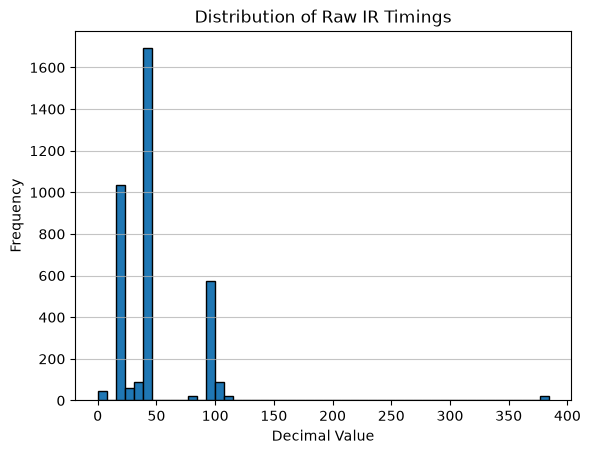

In [101]:
plt.hist(all_dec_codes, bins=50, edgecolor='black')
plt.title("Distribution of Raw IR Timings")
plt.xlabel("Decimal Value")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

We can observe some clustering around `20`, `40`, `100`. The **header** and **footer** are causing the outliers (the massive spike at the end and 0 at the start).

C:\Users\shres\AppData\Local\Temp\ipykernel_130172\462284032.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx][0].legend()
C:\Users\shres\AppData\Local\Temp\ipykernel_130172\462284032.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx][1].legend()
C:\Users\shres\AppData\Local\Temp\ipykernel_130172\462284032.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


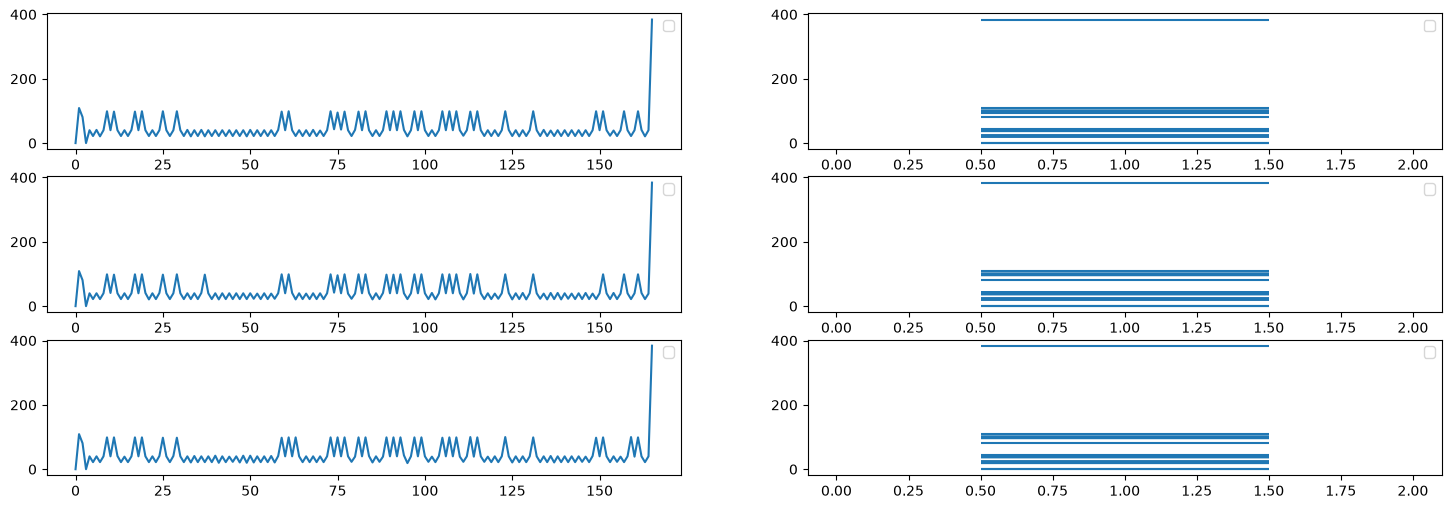

In [102]:
idx_selection = [0, 1, 2]

fig, axes = plt.subplots(len(idx_selection), 2, figsize=(18, 6))

for idx in idx_selection:
    decimal_values = pronto_codes[idx]['dec']
    axes[idx][0].plot(decimal_values, label=pronto_codes[idx]['label'])
    axes[idx][1].eventplot(decimal_values, orientation='vertical', label=pronto_codes[idx]['label'])
    axes[idx][0].legend()
    axes[idx][1].legend()

fig.show()

Let's remove the first 4 words (header) and the last 2 words (footer) from the pronto-codes. This will leave us with 160 datapoints.

In [103]:
# Remove the header and footer
for code in pronto_codes:
    code['hex'] = code['hex'][4:-2]
    code['dec'] = code['dec'][4:-2]

In [104]:
print(f"len(hex): {len(pronto_codes[0]['hex'])}")
print(f"len(dec): {len(pronto_codes[0]['dec'])}")

len(hex): 160
len(dec): 160


Let redo the frequency distribution analysis

In [105]:
all_hex_codes = []
all_dec_codes = []
for code in pronto_codes:
    all_hex_codes.extend(code["hex"])
    all_dec_codes.extend(code["dec"])



In [106]:
hex_counts = Counter(all_hex_codes)
hex_counts

Counter({'0028': 1093,
         '0016': 688,
         '0063': 406,
         '0029': 324,
         '0027': 216,
         '0015': 186,
         '0062': 143,
         '0017': 142,
         '0064': 64,
         '0026': 58,
         '0018': 39,
         '002A': 33,
         '0014': 19,
         '0065': 19,
         '0061': 17,
         '0025': 12,
         '0019': 9,
         '0024': 7,
         '002B': 5,
         '0066': 5,
         '0023': 5,
         '001E': 4,
         '001F': 4,
         '005F': 3,
         '0060': 3,
         '001A': 3,
         '0013': 2,
         '001B': 2,
         '0067': 2,
         '0022': 2,
         '001C': 2,
         '0068': 1,
         '0020': 1,
         '006C': 1})

In [107]:
dec_counts = Counter(all_dec_codes)
dec_counts

Counter({40: 1093,
         22: 688,
         99: 406,
         41: 324,
         39: 216,
         21: 186,
         98: 143,
         23: 142,
         100: 64,
         38: 58,
         24: 39,
         42: 33,
         20: 19,
         101: 19,
         97: 17,
         37: 12,
         25: 9,
         36: 7,
         43: 5,
         102: 5,
         35: 5,
         30: 4,
         31: 4,
         95: 3,
         96: 3,
         26: 3,
         19: 2,
         27: 2,
         103: 2,
         34: 2,
         28: 2,
         104: 1,
         32: 1,
         108: 1})

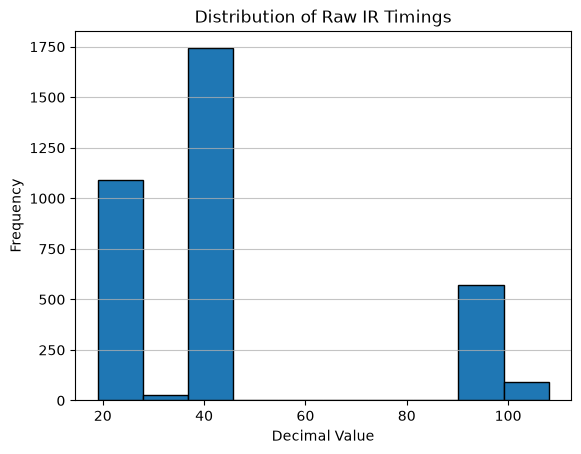

In [108]:
plt.hist(all_dec_codes, bins=10, edgecolor='black')
plt.title("Distribution of Raw IR Timings")
plt.xlabel("Decimal Value")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

C:\Users\shres\AppData\Local\Temp\ipykernel_130172\137265684.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx][0].legend()
C:\Users\shres\AppData\Local\Temp\ipykernel_130172\137265684.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx][1].legend()
C:\Users\shres\AppData\Local\Temp\ipykernel_130172\137265684.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


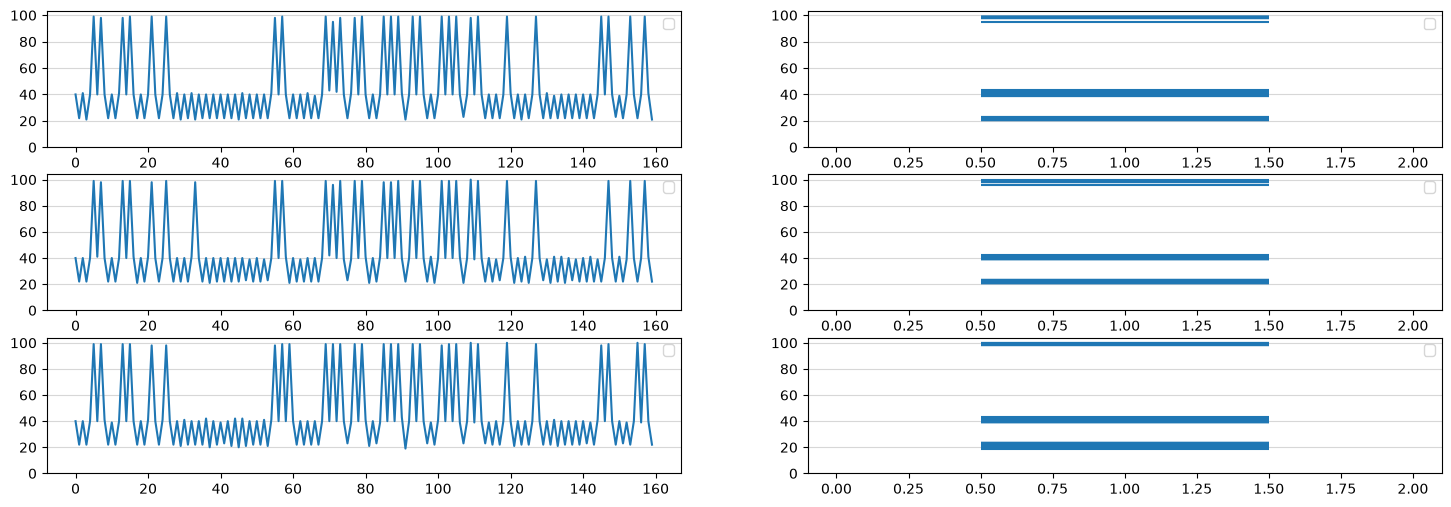

In [109]:
idx_selection = [0, 1, 2]

fig, axes = plt.subplots(len(idx_selection), 2, figsize=(18, 6))

for idx in idx_selection:
    decimal_values = pronto_codes[idx]['dec']
    axes[idx][0].plot(decimal_values, label=pronto_codes[idx]['label'])
    axes[idx][1].eventplot(decimal_values, orientation='vertical', label=pronto_codes[idx]['label'])
    axes[idx][0].legend()
    axes[idx][1].legend()
    axes[idx][0].set_yticks(range(0, 120, 20))
    axes[idx][1].set_yticks(range(0, 120, 20))
    axes[idx][0].grid(axis='y', alpha=0.5)
    axes[idx][1].grid(axis='y', alpha=0.5)

fig.show()

Much better. We can clearly see 3 bands clustered around `22`, `42` and `98`.

### Clustering the Frequencies

Visual inspection of the histogram reveals three distinct clusters. This aligns perfectly with how **Pulse Distance Modulation (PDM)** works in IR protocols:
1. A constant **Mark** (IR LED on).
2. A short **Space** representing a binary `0`.
3. A long **Space** representing a binary `1`.

In [110]:
import random

In [111]:
def kmeans(data: list[int], k: int = 3, max_iterations: int = 1000):
    """K-Means clustering implementation"""

    # Pick k unique random points as the starting centroids
    unique_data = list(set(data))

    # If we don't have enough points, just return what we have
    if len(unique_data) < k:
        return sorted(unique_data), {c: [c] for c in unique_data}

    # Pick k centroid randomly from the dataset
    centroids = random.sample(unique_data, k)

    clusters = {}
    for _ in range(max_iterations):
        # Create empty buckets for this iteration
        clusters = {c: [] for c in centroids}

        # Assign each data point to the closest centroid
        for point in data:
            nearest_centroid = min(centroids, key=lambda c: abs(c - point))
            clusters[nearest_centroid].append(point)

        # Calculate the new mean for each cluster
        new_centroids = []
        for c in centroids:
            if clusters[c]: # Avoid division by 0
                new_mean = sum(clusters[c]) / len(clusters[c])
                new_centroids.append(new_mean)
            else:
                new_centroids.append(c)

        # Convergence: Stop if centroids haven't moved
        if set(centroids) == set(new_centroids):
            break

        # Update the centroids for the next iteration
        centroids = new_centroids

    # Sort centroids so they are always ordered lowest to highest
    centroids.sort()

    # Re-key the clusters dictionary with the sorted centroids
    sorted_clusters = {c: clusters[c] for c in centroids}

    return [c for c in centroids], sorted_clusters

In [112]:
centroids, clusters = kmeans(all_dec_codes, k = 3)

print(f"Discovered Centroids: {centroids}\n")
for c in centroids:
    min_val = min(clusters[c])
    max_val = max(clusters[c])
    count = len(clusters[c])
    print(f"Center {round(c)} ({hex(round(c))}) | Count: {count:>4} | Range: {min_val} ({hex(min_val)}) to {max_val} ({hex(max_val)})")

Discovered Centroids: [22.10818181818182, 39.97949886104784, 98.91114457831326]

Center 22 (0x16) | Count: 1100 | Range: 19 (0x13) to 31 (0x1f)
Center 40 (0x28) | Count: 1756 | Range: 32 (0x20) to 43 (0x2b)
Center 99 (0x63) | Count:  664 | Range: 95 (0x5f) to 108 (0x6c)


The IR Protocol follows **Pulse Distance Modulation** and has an alternating Mark-Space sequence. Here we can observe that `41` appears 640 times which is the sum of `400` (for `21`) and `240` (for `98`). Since these datapoints are in pairs, `41` is the mark value while `21` (short-space) and `98` (long-space) would signify the bits.

## Binarization

Lets work under the assumption that `21` (short-space) represents the bit `0` and `98` (long-space) represents the bit `1`

In [113]:
# Calculate the thresholds using the centroids
midpoint_low = (centroids[0] + centroids[1]) / 2
midpoint_high = (centroids[1] + centroids[2]) / 2

print(f"Threshold for 0 (Short Space): < {midpoint_low:.2f}")
print(f"Threshold for 1 (Long Space): > {midpoint_high:.2f}\n")

Threshold for 0 (Short Space): < 31.04
Threshold for 1 (Long Space): > 69.45



In [114]:
for code in pronto_codes:
    bits = []

    # Extract the payload
    payload = code['dec']

    for val in payload:
        if val < midpoint_low:
            bits.append(0)
        elif val > midpoint_high:
            bits.append(1)

    code['bits'] = bits

In [115]:
_bits = "".join([str(b) for b in pronto_codes[0]['bits']])
_bits

'00110011001010000000000000011000001110110011101100111011000100010000000011001010'

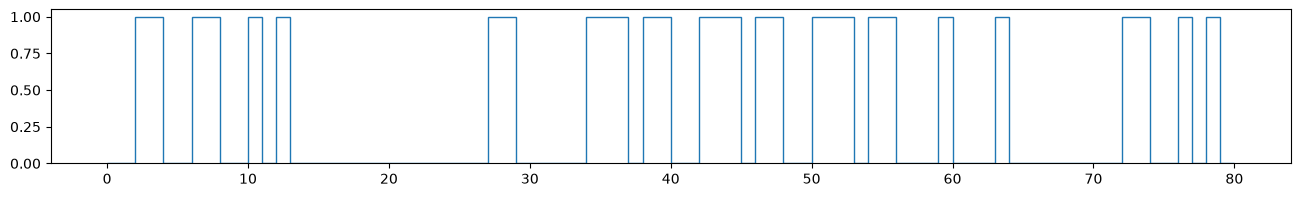

In [116]:
plt.figure(figsize=(16, 2))
plt.stairs(pronto_codes[0]['bits'])

In [117]:
len(_bits)

80

80 bits matches with the sequence length specified in the header and neatly specify 10 bytes of information.

## Bytes

In [118]:
for code in pronto_codes:
    code['bytes'] = []
    code['byteval'] = []
    for i in range(10):
        byte = "".join(str(b) for b in code['bits'][8*i:8*(i+1)])
        code['bytes'].append(byte)
        code['byteval'].append(int(byte, 2))

pronto_codes[0]['bytes']

['00110011',
 '00101000',
 '00000000',
 '00011000',
 '00111011',
 '00111011',
 '00111011',
 '00010001',
 '00000000',
 '11001010']

In [119]:
pronto_codes[0]['byteval']

[51, 40, 0, 24, 59, 59, 59, 17, 0, 202]

In [120]:
def get_code_by_label(label: str) -> dict | None:
    """Helper function to retrieve a pronto code by its label"""
    for code in pronto_codes:
        if code['label'] == label:
            return code
    return None

In [121]:
from IPython.display import display, HTML

In [122]:
byte_comparision_table = ""
byte_comparision_table += "<table>"

byte_comparision_table += "<tr><th>Label</th>"

for column in range(10):
    byte_comparision_table += f"<th>Byte {column}</th><th>Val {column}</th>"

byte_comparision_table += "</tr>"

for row in pronto_codes:
    byte_comparision_table += f"<tr><td>{row['label']}</td>"
    for byte, val in zip(row['bytes'], row['byteval']):
        byte_comparision_table += f"<td>{byte}</td><td>{val}</td>"
    byte_comparision_table += "</tr>"

byte_comparision_table += "</table>"

display(HTML(byte_comparision_table))

Label,Byte 0,Val 0,Byte 1,Val 1,Byte 2,Val 2,Byte 3,Val 3,Byte 4,Val 4,Byte 5,Val 5,Byte 6,Val 6,Byte 7,Val 7,Byte 8,Val 8,Byte 9,Val 9
__OFF,00110011,51,00101000,40,00000000,0,00011000,24,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,11001010,202
__ON,00110011,51,00101000,40,10000000,128,00011000,24,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,01001010,74
_PWR_OFF-28,00110011,51,00101000,40,00000000,0,00011100,28,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,11000110,198
_PWR_ON-28,00110011,51,00101000,40,10000000,128,00011100,28,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,01000110,70
_TEMP_17-to-16_CH,00110011,51,00101000,40,10000000,128,00010000,16,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,01010010,82
_TEMP_24-to-25_CH,00110011,51,00101000,40,10000000,128,00011001,25,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,01001001,73
_TEMP_25-to-26_CH,00110011,51,00101000,40,10000000,128,00011010,26,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,01001000,72
_TEMP_26-to-27_CH,00110011,51,00101000,40,10000000,128,00011011,27,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,01000111,71
_TEMP_27-to-26_CH,00110011,51,00101000,40,10000000,128,00011010,26,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,01001000,72
FAN_16C_Auto,00110011,51,11101000,232,10000000,128,00010000,16,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,10010010,146


Byte 3 seems to directly map to the **Temperature** value. Byte 2 looks like its the **Power** state of the AC. Byte 9 is possibly the checksum.

## Diff

In [123]:
def diff(*labels):
    """Compare two or more pronto codes by their labels"""
    if len(labels) < 2:
        print("Provide at least two labels to compare")
        return

    codes = [get_code_by_label(label) for label in labels]
    missing_labels = [label for label, code in zip(labels, codes) if not code]
    if missing_labels:
        print(f"Labels not found: {', '.join(missing_labels)}")
        return

    diff_table = "<table>"
    diff_table += "<tr><th>Byte</th>"
    for label in labels:
        diff_table += f"<th>{label}</th>"
    diff_table += "</tr>"

    for byte_index in range(10):
        byte_values = [code['bytes'][byte_index] for code in codes]
        has_difference = len(set(byte_values)) > 1

        diff_table += f"<tr><td>Byte {byte_index}</td>"
        for code, byte_value in zip(codes, byte_values):
            value = code['byteval'][byte_index]
            style = " style='background-color: #ffeeee'" if has_difference else ""
            diff_table += f"<td{style}>{byte_value}<br><small>{value}</small></td>"
        diff_table += "</tr>"

    diff_table += "</table>"
    display(HTML(diff_table))

In [124]:
diff("__OFF", "__ON")

Byte,__OFF,__ON
Byte 0,0011001151,0011001151
Byte 1,0010100040,0010100040
Byte 2,000000000,10000000128
Byte 3,0001100024,0001100024
Byte 4,0011101159,0011101159
Byte 5,0011101159,0011101159
Byte 6,0011101159,0011101159
Byte 7,0001000117,0001000117
Byte 8,000000000,000000000
Byte 9,11001010202,0100101074


Looks like the most-significant-bit (MSB) in Byte 2 represents the **Power** state of the AC. Not sure what the rest of the bits represent.

In [125]:
diff("__ON", "_TEMP_24-to-25_CH")

Byte,__ON,_TEMP_24-to-25_CH
Byte 0,0011001151,0011001151
Byte 1,0010100040,0010100040
Byte 2,10000000128,10000000128
Byte 3,0001100024,0001100125
Byte 4,0011101159,0011101159
Byte 5,0011101159,0011101159
Byte 6,0011101159,0011101159
Byte 7,0001000117,0001000117
Byte 8,000000000,000000000
Byte 9,0100101074,0100100173


In [126]:
diff("_TEMP_24-to-25_CH", "_TEMP_25-to-26_CH", "_TEMP_26-to-27_CH", "_TEMP_27-to-26_CH", "_TEMP_17-to-16_CH")

Byte,_TEMP_24-to-25_CH,_TEMP_25-to-26_CH,_TEMP_26-to-27_CH,_TEMP_27-to-26_CH,_TEMP_17-to-16_CH
Byte 0,0011001151,0011001151,0011001151,0011001151,0011001151
Byte 1,0010100040,0010100040,0010100040,0010100040,0010100040
Byte 2,10000000128,10000000128,10000000128,10000000128,10000000128
Byte 3,0001100125,0001101026,0001101127,0001101026,0001000016
Byte 4,0011101159,0011101159,0011101159,0011101159,0011101159
Byte 5,0011101159,0011101159,0011101159,0011101159,0011101159
Byte 6,0011101159,0011101159,0011101159,0011101159,0011101159
Byte 7,0001000117,0001000117,0001000117,0001000117,0001000117
Byte 8,000000000,000000000,000000000,000000000,000000000
Byte 9,0100100173,0100100072,0100011171,0100100072,0101001082


In [127]:
diff("_TEMP_26-to-27_CH", "_TEMP_27-to-26_CH")

Byte,_TEMP_26-to-27_CH,_TEMP_27-to-26_CH
Byte 0,0011001151,0011001151
Byte 1,0010100040,0010100040
Byte 2,10000000128,10000000128
Byte 3,0001101127,0001101026
Byte 4,0011101159,0011101159
Byte 5,0011101159,0011101159
Byte 6,0011101159,0011101159
Byte 7,0001000117,0001000117
Byte 8,000000000,000000000
Byte 9,0100011171,0100100072


As noted before, byte 3 represents the temperature value

In [128]:
diff('PWR_OFF-28', 'PWR_ON-28', '__OFF', '__ON')

Labels not found: PWR_OFF-28, PWR_ON-28


In [129]:
diff("FAN_16C_Auto", "FAN_16C_Low", "FAN_16C_Med", "FAN_16C_High", "TEMP_17-to-16_CH")

Labels not found: TEMP_17-to-16_CH


In [130]:
diff('MODE_CH_21', 'MODE_DL_24', 'MODE_SA_23', 'MODE_FH_00')

Byte,MODE_CH_21,MODE_DL_24,MODE_SA_23,MODE_FH_00
Byte 0,0011001151,0011001151,0011001151,0011001151
Byte 1,0010100040,10000100132,11100010226,0010000133
Byte 2,10000000128,10000000128,10000000128,10000000128
Byte 3,0001010121,0001100024,0001011123,0001011123
Byte 4,0011101159,0011101159,0011101159,0011101159
Byte 5,0011101159,0011101159,0011101159,0011101159
Byte 6,0011101159,0011101159,0011101159,0011101159
Byte 7,0001000117,0001000117,0001000117,0001000117
Byte 8,000000000,000000000,000000000,000000000
Byte 9,0100110177,11101110238,10010001145,0101001082


**Cool**: Full Control
**Drop**: No Temperature or Fan Control or Turbo. Fixed at 24 Drop Fan Low,
**Sun**: No response from my AC. Can change temp and fan speed but does nothing. Defaults to 23 Fan Auto. No Turbo Mode though.
**Fan**: No temperature. Fan speed control only. No Fan Auto. No Turbo.

In [131]:
diff("__ON", "SWITCH_HSwing")

Byte,__ON,SWITCH_HSwing
Byte 0,0011001151,0011001151
Byte 1,0010100040,0010100040
Byte 2,10000000128,10000000128
Byte 3,0001100024,0001100024
Byte 4,0011101159,0011101159
Byte 5,0011101159,0011101159
Byte 6,0011101159,0011101159
Byte 7,0001000117,0001000117
Byte 8,000000000,0001000016
Byte 9,0100101074,0011101058


In [132]:
diff("__ON", "SWITCH_VSwing")

Byte,__ON,SWITCH_VSwing
Byte 0,0011001151,0011001151
Byte 1,0010100040,0010100040
Byte 2,10000000128,10000111135
Byte 3,0001100024,0001100024
Byte 4,0011101159,0011101159
Byte 5,0011101159,0011101159
Byte 6,0011101159,0011101159
Byte 7,0001000117,0001000117
Byte 8,000000000,000000000
Byte 9,0100101074,0100001167


In [133]:
diff("__ON", "SWITCH_EcoSaver")

Byte,__ON,SWITCH_EcoSaver
Byte 0,0011001151,0011001151
Byte 1,0010100040,0100100072
Byte 2,10000000128,10000000128
Byte 3,0001100024,0101100088
Byte 4,0011101159,0011101159
Byte 5,0011101159,0011101159
Byte 6,0011101159,0011101159
Byte 7,0001000117,0001000117
Byte 8,000000000,000000000
Byte 9,0100101074,11101010234


In [134]:
diff("__ON", "SWITCH_Lamp")

Byte,__ON,SWITCH_Lamp
Byte 0,0011001151,0011001151
Byte 1,0010100040,0010100040
Byte 2,10000000128,10000000128
Byte 3,0001100024,0001100024
Byte 4,0011101159,0011101159
Byte 5,0011101159,0011101159
Byte 6,0011101159,0011101159
Byte 7,0001000117,0001000117
Byte 8,000000000,0010000032
Byte 9,0100101074,0010101042


In [135]:
diff("__ON", "SWITCH_Turbo")

Byte,__ON,SWITCH_Turbo
Byte 0,0011001151,0011001151
Byte 1,0010100040,0010100040
Byte 2,10000000128,10100000160
Byte 3,0001100024,0001100024
Byte 4,0011101159,0011101159
Byte 5,0011101159,0011101159
Byte 6,0011101159,0011101159
Byte 7,0001000117,0001000117
Byte 8,000000000,000000000
Byte 9,0100101074,000001015
